# GBM for ETF Cross-Asset Rotation

Gradient boosting tests whether cross-asset rotation benefits from non-linear
feature interactions. The HMM stress state (31% of the sample from Ch9)
may interact with momentum in ways that linear models cannot capture -
for example, momentum reversals triggered by regime transitions. The grid
covers 5 leaf-count profiles × 3 loss functions = 15 configurations, with
IC evaluated at 50-iteration checkpoints to detect overfitting.

**Learning Objectives**:
- Compare tree depth profiles (7 to 63 leaves) on walk-forward CV
- Track IC learning curves to identify overfitting dynamics
- Determine whether non-linearity improves on the linear baseline
- Evaluate whether the 99-symbol cross-section is large enough for stable tree splits

**Book Reference**: Chapter 12, Section 12.8 (Case Study Results)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`,
[`06_linear`](06_linear.ipynb)

In [1]:
"""GBM Grid Search - config-driven regularization profiles × loss functions."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import Markdown, display

from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    train_gbm_config,
)
from case_studies.utils.latent_factors.case_study import _training_input_identity
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    load_training_runs,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

# Device: read from setup.yaml, fall back to GPU detection
gbm_config = setup.get("modeling", {}).get("gbm", {})
DEVICE = gbm_config.get("device", "cuda")
MAX_BIN = 63  # GPU default
import torch

if DEVICE != "cpu" and not torch.cuda.is_available():
    DEVICE, MAX_BIN = "cpu", 255

print(f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | max_bin: {MAX_BIN}")

Case study: etfs | Device: gpu | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
input_data_spec = _training_input_identity(CASE_STUDY_ID, PRIMARY_LABEL)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")
print(f"Input digest: {input_data_spec['input_digest']}")

Dataset: 394,233 rows × 71 features
Label: fwd_ret_21d | Task: regression | Folds: 8
Input digest: sha256:8384ded464c95f36b9baff06cd6a7861db75650ff9244ac623c3c7bf662281a8


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

print(f"\n{len(configs)} configs × {len(splits)} folds\n")
for cfg in configs:
    leaves = cfg["params"].get("num_leaves", 31)
    obj = cfg["params"].get("objective", "regression")
    n_trees = cfg.get("max_iterations", 500)
    print(f"  {cfg['config_name']:25s}  leaves={leaves:3d}  obj={obj}  trees={n_trees}")


15 configs × 8 folds

  default_mse                leaves= 31  obj=regression  trees=500
  default_mae                leaves= 31  obj=regression_l1  trees=500
  default_huber              leaves= 31  obj=huber  trees=500
  leaves_7_mse               leaves=  7  obj=regression  trees=500
  leaves_7_mae               leaves=  7  obj=regression_l1  trees=500
  leaves_7_huber             leaves=  7  obj=huber  trees=500
  leaves_15_mse              leaves= 15  obj=regression  trees=500
  leaves_15_mae              leaves= 15  obj=regression_l1  trees=500
  leaves_15_huber            leaves= 15  obj=huber  trees=500
  leaves_31_mse              leaves= 31  obj=regression  trees=500
  leaves_31_mae              leaves= 31  obj=regression_l1  trees=500
  leaves_31_huber            leaves= 31  obj=huber  trees=500
  leaves_63_mse              leaves= 63  obj=regression  trees=500
  leaves_63_mae              leaves= 63  obj=regression_l1  trees=500
  leaves_63_huber            leaves= 63  obj

## 2. Prepare CV Folds

GBM folds use float32 (LightGBM native precision) and skip
imputation/scaling - gradient boosting handles missing values natively.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=227,101  val=24,190
  Fold 1: train=222,805  val=23,940
  Fold 2: train=217,733  val=23,940
  Fold 3: train=210,654  val=23,942
  Fold 4: train=203,290  val=24,192
  Fold 5: train=192,472  val=24,186
  Fold 6: train=179,598  val=23,664
  Fold 7: train=157,397  val=22,180


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations) to
detect overfitting - configs that peak early and decay indicate too much capacity.

In [7]:
results = []
for cfg in configs:
    # Pre-compute registry training dir so boosters go directly there
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        extra_params={"input_data_spec": input_data_spec},
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _status = training_run_status(CASE_STUDY_ID, spec)
    _training_hash = training_hash_from_spec(spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        # Already trained + registered: rebuild a minimal result from the
        # registry so the grid + learning-curve sections render on a
        # fully-cached checkout. (A bare `continue` here drops the config
        # from `results`, printing an empty grid when every config is
        # registered.) best_ic is the authoritative registered value;
        # best_iter and the curves come from learning_curves.parquet.
        _pred_hash = _split_rows["prediction_hash"][0]
        _metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=_pred_hash)
        _best_ic = float(_metrics["ic_mean"][0]) if not _metrics.is_empty() else float("nan")
        # ic_n_days = number of validation dates that produced a defined daily IC.
        # A config that predicts near-constant on some folds yields no cross-sectional
        # IC on those dates and a partial ic_n_days below the full-coverage maximum.
        # Section 4 uses this to keep any partial-coverage config out of the ranking.
        _ic_n_days = float(_metrics["ic_n_days"][0]) if not _metrics.is_empty() else float("nan")
        _curves = []
        _lc_path = train_dir / "learning_curves.parquet"
        if _lc_path.exists():
            _curves = pl.read_parquet(_lc_path).to_dicts()
        _best_iter = 0
        if _curves:
            _best_iter = int(max(_curves, key=lambda c: c["ic_mean"])["iteration"])
        print(
            f"  {cfg['config_name']:25s}  iter={_best_iter:4d}  IC={_best_ic:+.4f}  "
            f"(cached, {_status.summary()})"
        )
        results.append(
            {
                "config_name": cfg["config_name"],
                "best_iter": _best_iter,
                "best_ic": _best_ic,
                "ic_n_days": _ic_n_days,
                "elapsed_s": 0.0,
                "learning_curves": _curves,
                "cached": True,
            }
        )
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {_status.summary()}")

    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({result['elapsed_s']:.0f}s)"
    )

    # Register immediately after training - incremental save protects against
    # interruption losing work on large sweeps.
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
        input_data_spec=input_data_spec,
    )
    _registered_splits = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    if not _registered_splits.is_empty():
        _registered_metrics = load_prediction_metrics(
            CASE_STUDY_ID,
            prediction_hash=_registered_splits["prediction_hash"][0],
        )
        if not _registered_metrics.is_empty() and "ic_n_days" in _registered_metrics.columns:
            result["ic_n_days"] = float(_registered_metrics["ic_n_days"][0])

  default_mse                iter= 100  IC=+0.0133  (cached, complete (hash=2bb91d24af97))
  default_mae                iter=  50  IC=+0.0407  (cached, complete (hash=c0e9eb77453b))
  default_huber              iter= 100  IC=+0.0133  (cached, complete (hash=4eaaf0e5bd9a))
  leaves_7_mse               iter=  50  IC=+0.0480  (cached, complete (hash=a3c4ce50efc9))
  leaves_7_mae               iter=  50  IC=+0.0513  (cached, complete (hash=a75d810ea1ad))
  leaves_7_huber             iter=  50  IC=+0.0480  (cached, complete (hash=4cbbb5158e33))
  leaves_15_mse              iter=  50  IC=+0.0407  (cached, complete (hash=fd364762dfc8))
  leaves_15_mae              iter= 100  IC=+0.0337  (cached, complete (hash=306da47bc77e))
  leaves_15_huber            iter=  50  IC=+0.0407  (cached, complete (hash=0181dfabae65))
  leaves_31_mse              iter=  50  IC=+0.0179  (cached, complete (hash=02e77b54e710))
  leaves_31_mae              iter= 100  IC=+0.0453  (cached, complete (hash=efec375dc03c))

## 4. Grid Results

Configs are ranked by their validation IC. Each config's reported IC is its
**peak-checkpoint** value: for every config the tree count is tuned on the
validation folds by scanning the same 50-iteration checkpoint grid (50, 100,
..., 500) and keeping the checkpoint with the highest mean cross-sectional IC.
Because all configs share the identical checkpoint grid, this validation-based
choice of boosting rounds is comparable across the grid (it is the tree-count
analogue of early stopping) and does not favor one config over another. The
holdout is never touched here.

A full-coverage guard mirrors `06_linear` and `13_model_analysis`: a config that
collapses to near-constant predictions on some folds produces no cross-sectional
IC on those validation dates, so its IC is measured on fewer days (`ic_n_days`
below the full-coverage maximum) and is not comparable to a full-coverage IC.
Such configs are listed separately and excluded from the ranking and the winner.
The guard is active whenever a configuration produces fewer defined daily IC
observations than the maximum available in the current registry.

In [8]:
results.sort(key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True)

# Full-coverage split (see markdown above). On a pure-retrain checkout ic_n_days is
# not yet known inline, so the guard falls back to the full result set.
_finite_days = [r["ic_n_days"] for r in results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in results if r not in full_cov]
else:
    _full_days = None
    full_cov = results
    partial_cov = []

best = full_cov[0] if full_cov else None

print(f"{'Config':25s}  {'Iter':>5s}  {'IC':>8s}  {'N Days':>7s}")
print("-" * 52)
for r in full_cov:
    marker = " *" if r is best else ""
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>7d}" if np.isfinite(_nd) else f"{'n/a':>7s}"
    print(f"  {r['config_name']:25s}  {r['best_iter']:5d}  {r['best_ic']:+.4f}  {_nd_str}{marker}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds - excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(
            f"  {r['config_name']:25s}  IC={r['best_ic']:+.4f}  "
            f"n_days={_nd_str} (of {int(_full_days)})"
        )

if best:
    print(
        f"\nBest (full coverage): {best['config_name']} @ {best['best_iter']} trees "
        f"(IC={best['best_ic']:+.4f})"
    )

Config                      Iter        IC   N Days
----------------------------------------------------
  leaves_7_mae                  50  +0.0513     2016 *
  leaves_31_mae                100  +0.0453     2016
  leaves_15_mse                 50  +0.0407     2016
  leaves_15_huber               50  +0.0407     2016
  default_mae                   50  +0.0407     2016
  leaves_63_mae                 50  +0.0383     2016
  leaves_15_mae                100  +0.0337     2016
  leaves_63_mse                100  +0.0238     2016
  leaves_63_huber              100  +0.0238     2016
  leaves_31_mse                 50  +0.0179     2016
  leaves_31_huber               50  +0.0179     2016
  default_mse                  100  +0.0133     2016
  default_huber                100  +0.0133     2016

Partial coverage (degenerate on some folds - excluded from ranking):
  leaves_7_mse               IC=+0.0480  n_days=2009 (of 2016)
  leaves_7_huber             IC=+0.0480  n_days=2009 (of 2016)

Best (f

### IC by configuration

The bar chart ranks the full-coverage GBM configs by validation IC, colored by
loss function. MAE-loss configs cluster at the top and squared-error/Huber
configs trail, so the choice of loss matters more than tree depth on this
cross-section.

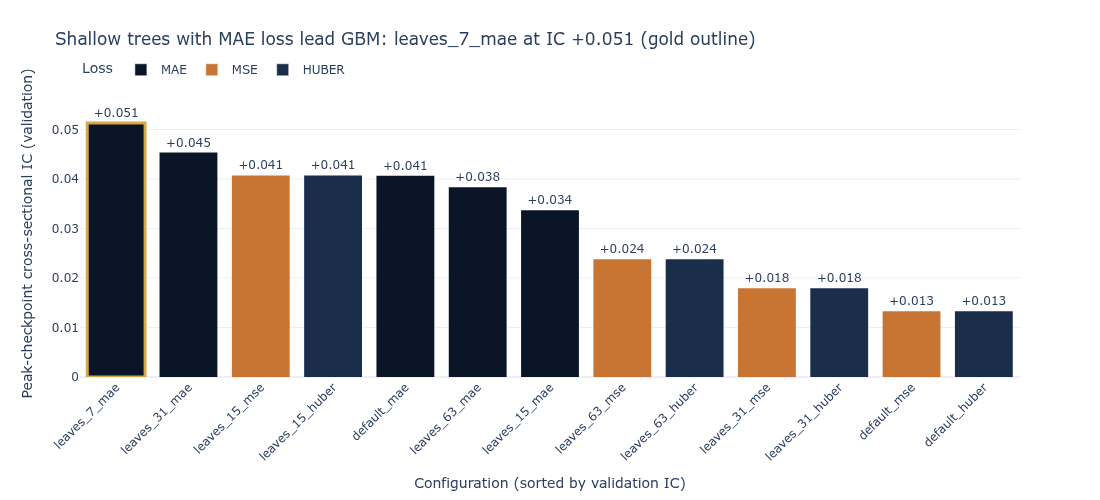

In [9]:
# Figure 1 - IC-by-config bar, colored by loss, winner outlined.
_LOSS_COLOR = {"mae": COLORS["blue"], "mse": COLORS["copper"], "huber": COLORS["slate"]}


def _loss_of(name: str) -> str:
    for loss in ("mae", "mse", "huber"):
        if name.endswith(loss):
            return loss
    return "other"


_names = [r["config_name"] for r in full_cov]
_ics = [r["best_ic"] for r in full_cov]
_losses = [_loss_of(n) for n in _names]
_leader = best["config_name"] if best else None
_bar_colors = [_LOSS_COLOR.get(loss, COLORS["silver"]) for loss in _losses]
_line_w = [3 if n == _leader else 0 for n in _names]
fig_ic = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker=dict(color=_bar_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.3f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
# Legend proxies for the three loss functions.
for loss in ("mae", "mse", "huber"):
    fig_ic.add_trace(
        go.Bar(
            x=[None],
            y=[None],
            marker_color=_LOSS_COLOR[loss],
            name=loss.upper(),
            showlegend=True,
        )
    )
_lead_ic = best["best_ic"] if best else float("nan")
fig_ic.update_layout(
    title=(f"Shallow trees with MAE loss lead GBM: {_leader} at IC {_lead_ic:+.3f} (gold outline)"),
    template="plotly_white",
    height=500,
    width=1100,
    barmode="overlay",
    legend=dict(title="Loss", orientation="h", yanchor="bottom", y=1.02, x=0),
    margin=dict(t=90),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_ic.show()

## 5. Learning Curves

Validation IC at each 50-iteration checkpoint traces the overfitting dynamics.
The winner and the deep-tree configs peak early and then decay - added capacity
fits fold-specific noise rather than transferable cross-sectional structure -
while the shallow-tree configs stay flatter, the signature of adequate
regularization. The vertical line marks the winner's selected tree count.

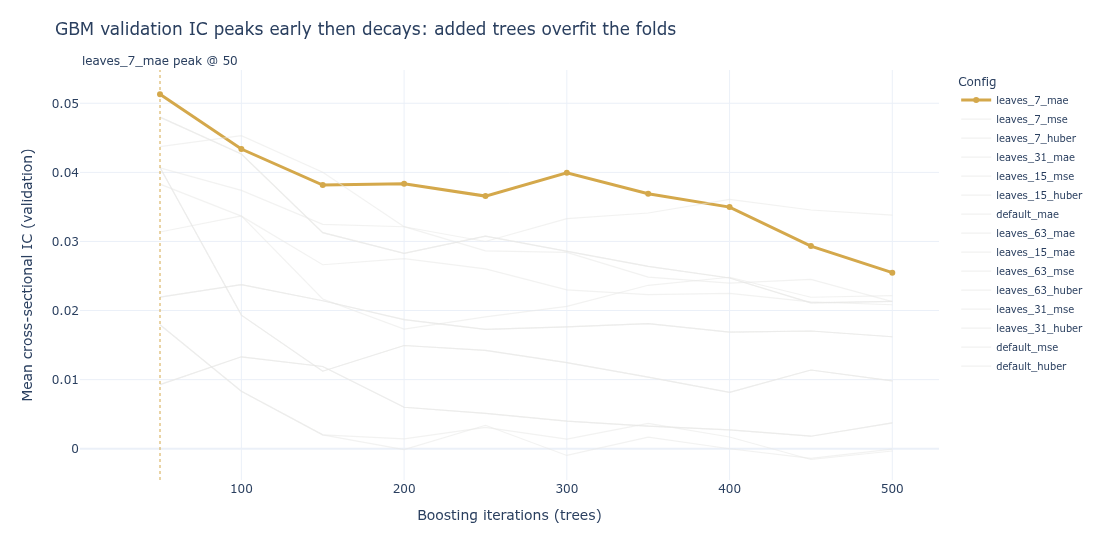

Config                         50     100     200     300     500
  leaves_7_mae              +0.0513 +0.0434 +0.0383 +0.0399 +0.0255
  leaves_7_mse              +0.0480 +0.0427 +0.0283 +0.0286 +0.0213
  leaves_7_huber            +0.0480 +0.0427 +0.0283 +0.0286 +0.0213
  leaves_31_mae             +0.0437 +0.0453 +0.0321 +0.0284 +0.0213
  leaves_15_mse             +0.0407 +0.0193 +0.0149 +0.0124 +0.0098
  leaves_15_huber           +0.0407 +0.0193 +0.0149 +0.0124 +0.0098
  default_mae               +0.0407 +0.0374 +0.0321 +0.0333 +0.0338
  leaves_63_mae             +0.0383 +0.0337 +0.0275 +0.0230 +0.0208
  leaves_15_mae             +0.0314 +0.0337 +0.0173 +0.0206 +0.0221
  leaves_63_mse             +0.0219 +0.0238 +0.0187 +0.0176 +0.0162
  leaves_63_huber           +0.0219 +0.0238 +0.0187 +0.0176 +0.0162
  leaves_31_mse             +0.0179 +0.0083 -0.0001 -0.0010 -0.0001
  leaves_31_huber           +0.0179 +0.0083 +0.0014 +0.0014 -0.0003
  default_mse               +0.0093 +0.0133 +0.006

In [10]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
if all_curves.height > 0:
    # Figure 2 - checkpoint learning curves (IC vs iteration), winner highlighted.
    fig_lc = go.Figure()
    for r in results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"]).sort("iteration")
        if cfg_data.height == 0:
            continue
        is_winner = best is not None and r["config_name"] == best["config_name"]
        fig_lc.add_trace(
            go.Scatter(
                x=cfg_data["iteration"].to_list(),
                y=cfg_data["ic_mean"].to_list(),
                mode="lines+markers" if is_winner else "lines",
                name=r["config_name"],
                line=dict(
                    color=COLORS["amber"] if is_winner else COLORS["silver_muted"],
                    width=3 if is_winner else 1.2,
                ),
                marker=dict(size=6),
                opacity=1.0 if is_winner else 0.55,
            )
        )
    if best is not None:
        fig_lc.add_vline(
            x=best["best_iter"],
            line=dict(color=COLORS["amber"], width=1, dash="dot"),
            annotation_text=f"{best['config_name']} peak @ {best['best_iter']}",
            annotation_position="top",
        )
    fig_lc.update_layout(
        title="GBM validation IC peaks early then decays: added trees overfit the folds",
        template="plotly_white",
        height=560,
        width=1100,
        legend=dict(title="Config", font=dict(size=10)),
        margin=dict(t=70),
    )
    fig_lc.update_xaxes(title_text="Boosting iterations (trees)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

    # Compact checkpoint table for the exact values behind the curves.
    checkpoints = sorted(all_curves["iteration"].unique().to_list())
    display_cps = [cp for cp in [50, 100, 200, 300, 500] if cp in checkpoints]

    print(f"{'Config':25s}", end="")
    for cp in display_cps:
        print(f" {cp:>7d}", end="")
    print()

    for r in results:
        cfg_data = all_curves.filter(pl.col("config") == r["config_name"])
        print(f"  {r['config_name']:25s}", end="")
        for cp in display_cps:
            row = cfg_data.filter(pl.col("iteration") == cp)
            if row.height > 0:
                print(f" {row['ic_mean'][0]:+7.4f}", end="")
            else:
                print(f" {'N/A':>7s}", end="")
        print()

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
This protects against interruption - all completed configs are already
persisted in `run_log/registry.db`.

In [11]:
print(f"All {len(results)} configs registered.")

# Read the current full-coverage linear leader for a live model-family comparison.
_linear_rows = []
for _run in load_training_runs(CASE_STUDY_ID, family="linear", label=label_col).to_dicts():
    _predictions = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_run["training_hash"],
        split=PREDICTION_SPLIT,
    )
    if _predictions.is_empty():
        continue
    _metrics = load_prediction_metrics(
        CASE_STUDY_ID,
        prediction_hash=_predictions["prediction_hash"][0],
    )
    if _metrics.is_empty():
        continue
    _linear_rows.append(
        {
            "config_name": _run["config_name"],
            "ic": float(_metrics["ic_mean_daily"][0]),
            "n_days": int(_metrics["ic_n_days"][0]),
        }
    )

_linear_full_days = max((row["n_days"] for row in _linear_rows), default=0)
_linear_full = [row for row in _linear_rows if row["n_days"] == _linear_full_days]
_linear_best = max(_linear_full, key=lambda row: row["ic"], default=None)

_backend = "unknown"
if best is not None:
    _winner_config = next(cfg for cfg in configs if cfg["config_name"] == best["config_name"])
    _winner_spec = build_training_spec(
        "gbm",
        best["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=_winner_config.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        extra_params={"input_data_spec": input_data_spec},
    )
    _booster = get_training_dir(CASE_STUDY_ID, _winner_spec) / "boosters" / "fold_0.txt"
    if _booster.exists():
        _booster_text = _booster.read_text()
        for _candidate in ("cuda", "gpu", "cpu"):
            if f"[device_type: {_candidate}]" in _booster_text:
                _backend = _candidate.upper()
                break

All 15 configs registered.


In [12]:
if best is not None:
    _linear_sentence = "The current registry contains no comparable full-coverage linear fit."
    if _linear_best is not None:
        _delta = best["best_ic"] - _linear_best["ic"]
        _linear_sentence = (
            f"It exceeds the full-coverage linear leader `{_linear_best['config_name']}` "
            f"(IC {_linear_best['ic']:+.3f}) by {_delta:+.3f}."
        )
    _partial_sentence = (
        f" {len(partial_cov)} configurations are excluded from the ranking because they "
        f"produce fewer than {int(_full_days)} defined daily IC observations."
        if partial_cov
        else " All configurations have full daily coverage."
    )
    display(
        Markdown(
            f"""
## 7. Key Takeaways

- **A shallow MAE tree leads.** `{best["config_name"]}` is the full-coverage winner at
  validation IC {best["best_ic"]:+.3f}, peaking at {best["best_iter"]} trees. The wider grid
  shows that neither loss alone nor extra depth guarantees better validation rankings.
- **The non-linear increment is positive but modest.** {_linear_sentence}
- **Coverage and early overfitting matter.**{_partial_sentence} Tree count is selected on the
  shared validation checkpoint grid; the holdout remains untouched.
- **Execution provenance.** The saved winning boosters report the `{_backend}` LightGBM backend.

The next notebooks test whether TabM and sequence models capture structure that a
cross-sectional GBM cannot exploit.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests TabM as a bridge between linear and
sequence models; [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) tests channel mixing on the
cross-asset temporal structure.
"""
        )
    )


## 7. Key Takeaways

- **A shallow MAE tree leads.** `leaves_7_mae` is the full-coverage winner at
  validation IC +0.051, peaking at 50 trees. The wider grid
  shows that neither loss alone nor extra depth guarantees better validation rankings.
- **The non-linear increment is positive but modest.** It exceeds the full-coverage linear leader `ridge_a1000000.0` (IC +0.042) by +0.009.
- **Coverage and early overfitting matter.** 2 configurations are excluded from the ranking because they produce fewer than 2016 defined daily IC observations. Tree count is selected on the
  shared validation checkpoint grid; the holdout remains untouched.
- **Execution provenance.** The saved winning boosters report the `CPU` LightGBM backend.

The next notebooks test whether TabM and sequence models capture structure that a
cross-sectional GBM cannot exploit.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests TabM as a bridge between linear and
sequence models; [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) tests channel mixing on the
cross-asset temporal structure.
